In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
tmodvic = pd.read_csv('C:\\Users\\Santiago Gonz\\Desktop\\ENVIPE 2025\\TMod_Vic.csv')
tpervic1 = pd.read_csv('C:\\Users\\Santiago Gonz\\Desktop\\ENVIPE 2025\\TPer_Vic1.csv')

In [4]:
tpervic1.head()

,Unnamed: 0,ID_VIV,ID_HOG,ID_PER,UPM,VIV_SEL,HOGAR,RESUL_H,R_SEL,SEXO,...,AP5_8_11_5,AP5_9,FAC_HOG,FAC_ELE,FAC_HOG_AM,FAC_ELE_AM,DOMINIO,ESTRATO,EST_DIS,UPM_DIS
0,1,100107.01,0100107.01.01,0100107.01.01.01,100107,1,1,B,1,2,...,NaN,3,241,241,241.0,241.0,U,2,1,47
1,2,100107.02,0100107.02.01,0100107.02.01.02,100107,2,1,A,2,2,...,9.0,2,241,482,241.0,482.0,U,2,1,47
2,3,100107.03,0100107.03.01,0100107.03.01.04,100107,3,1,B,4,2,...,NaN,9,241,963,241.0,963.0,U,2,1,47
3,4,100107.04,0100107.04.01,0100107.04.01.03,100107,4,1,A,3,1,...,9.0,2,241,723,241.0,723.0,U,2,1,47
4,5,100107.05,0100107.05.01,0100107.05.01.01,100107,5,1,B,1,2,...,NaN,2,241,482,241.0,482.0,U,2,1,47


# Analisis exploratorio

In [120]:
cols = ['AP4_10_01','AP4_10_03','AP4_10_07','AP4_10_08', 'AP4_10_09','AP4_10_11','AP4_10_13','AP4_10_14']
df= tpervic1[['ID_PER'] + cols + ['FAC_ELE']].copy()

# Nos quedamos solo con las resputas afirmativas
df[cols] = (df[cols] == 1).astype(int)

# Construimos una dummy que será nuestra variable endógena
df['Y'] = df[cols].any(axis=1).astype(int)
df

,ID_PER,AP4_10_01,AP4_10_03,AP4_10_07,AP4_10_08,AP4_10_09,AP4_10_11,AP4_10_13,AP4_10_14,FAC_ELE,Y
0,0100107.01.01.01,1,1,0,0,1,1,0,0,241,1
1,0100107.02.01.02,0,0,0,0,0,0,0,0,482,0
2,0100107.03.01.04,1,1,0,0,1,1,0,0,963,1
3,0100107.04.01.03,0,0,0,0,0,0,0,0,723,0
4,0100107.05.01.01,0,0,0,0,0,0,0,0,482,0
...,...,...,...,...,...,...,...,...,...,...,...
91177,3261231.16.01.01,1,0,0,0,1,0,0,0,282,1
91178,3261231.17.01.01,1,1,0,0,1,1,1,0,282,1
91179,3261231.18.01.01,1,1,0,0,1,1,0,0,282,1
91180,3261231.19.01.02,0,0,0,0,0,0,0,0,564,0


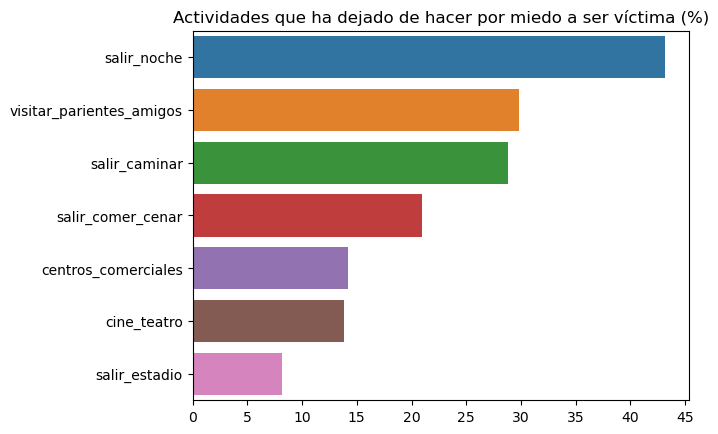

In [113]:
preguntas_dict = {
    'AP4_10_01': 'salir_noche',
    'AP4_10_03': 'visitar_parientes_amigos',
    'AP4_10_08': 'cine_teatro',
    'AP4_10_09': 'salir_caminar',
    'AP4_10_11': 'salir_comer_cenar',
    'AP4_10_13': 'salir_estadio',
    'AP4_10_14': 'centros_comerciales'}

# Multiplicar por pesos
actividades = df[cols].mul(df['FAC_ELE'], axis=0)

# Sumar por columna
actividades_sum = actividades.sum().reset_index()
actividades_sum.columns = ['actividad', 'total']
actividades_sum['total'] = actividades_sum['total']*100/(tpervic1['FAC_ELE'].sum())

# Renombrar
actividades_sum['actividad'] = actividades_sum['actividad'].map(rename_dict)

# Ordenar
actividades_sum = actividades_sum.sort_values(by='total', ascending=False)

# Graficar
sns.barplot(data=actividades_sum, x='total', y='actividad')
plt.title('Actividades que ha dejado de hacer por miedo a ser víctima (%)')
plt.ylabel('')
plt.xlabel('')
max_val = actividades_sum['total'].max()
plt.xticks(np.arange(0, max_val + 5, 5))
plt.show()

In [117]:
actividades_sum

,actividad,total
0,salir_noche,43.181924
1,visitar_parientes_amigos,29.798516
4,salir_caminar,28.830801
5,salir_comer_cenar,20.963935
7,centros_comerciales,14.224941
3,cine_teatro,13.786918
6,salir_estadio,8.143728
2,NaN,0.705289


In [121]:
RestTotal = (df['FAC_ELE'] * df['Y']).sum()
print('La población total que restringió su movilidad es', RestTotal)
print('La población que restringió al menos una actividad es', RestTotal / tpervic1['FAC_ELE'].sum()*100, '%')

La población total que restringió su movilidad es 51779321
La población que restringió al menos una actividad es 54.051776602267864 %


In [122]:
# Ahora construimos la tasa de delitos por municipio

# Delitos totales por municipio
tasamun = tmodvic.groupby('BP1_3C', as_index=False)['FAC_DEL'].sum()
tasamun = tasamun.rename(columns={'BP1_3C':'CVE_MUN'})

# Población de cada municipio
pobmun = tpervic1.groupby('CVE_MUN', as_index=False)['FAC_ELE'].sum()

# Merge y tasa
tasamun = pd.merge(tasamun, pobmun, on='CVE_MUN')
tasamun['tasamun'] = tasamun['FAC_DEL'] / tasamun['FAC_ELE']
tasamun

,CVE_MUN,FAC_DEL,FAC_ELE,tasamun
0,1,865473,2598506,0.333066
1,2,679320,2319778,0.292838
2,3,637846,1756653,0.363103
3,4,1109058,2945479,0.376529
4,5,1410683,2852542,0.494535
...,...,...,...,...
217,551,11260,40929,0.275111
218,557,3909,17415,0.224462
219,565,10970,51330,0.213715
220,567,4164,20358,0.204539


In [123]:
# Tasa segun tipo de delito
map_delitos = {
    1: 'patrimonial', 2: 'patrimonial', 3: 'patrimonial', 4: 'patrimonial',
    6: 'patrimonial', 7: 'patrimonial', 8: 'patrimonial', 15: 'patrimonial',
    5: 'violento', 9: 'violento', 10: 'violento', 11: 'violento',
    12: 'extremo', 13: 'extremo', 14: 'extremo'
}

tmodvic['tipo_delito'] = tmodvic['BPCOD'].map(map_delitos).fillna('otro')

# Groupby por municipio y tipo de delito
delitos_mun_tipo = (
    tmodvic
    .groupby(['BP1_3C', 'tipo_delito'], as_index=False)['FAC_DEL']
    .sum()
)

# Pasar categorías a columnas
delitos_mun_tipo = (
    delitos_mun_tipo
    .pivot(index='BP1_3C', columns='tipo_delito', values='FAC_DEL')
    .reset_index()
    .fillna(0)
)


# Pasamos a tasa
delitos_mun_tipo = delitos_mun_tipo.rename(columns={'BP1_3C':'CVE_MUN'})
delitos_mun_tipo = pd.merge(delitos_mun_tipo, pobmun, on='CVE_MUN')
delitos_mun_tipo['extremotasa'] = delitos_mun_tipo['extremo'] / delitos_mun_tipo['FAC_ELE']
delitos_mun_tipo['patrimonialtasa'] = delitos_mun_tipo['patrimonial'] / delitos_mun_tipo['FAC_ELE']
delitos_mun_tipo['violentotasa'] = delitos_mun_tipo['violento'] / delitos_mun_tipo['FAC_ELE']


delitos_mun_tipo

,CVE_MUN,extremo,patrimonial,violento,FAC_ELE,extremotasa,patrimonialtasa,violentotasa
0,1,28606.0,435653.0,401214.0,2598506,0.011009,0.167655,0.154402
1,2,52627.0,340820.0,285873.0,2319778,0.022686,0.146919,0.123233
2,3,68414.0,284968.0,284464.0,1756653,0.038946,0.162222,0.161935
3,4,47809.0,486326.0,574923.0,2945479,0.016231,0.165109,0.195188
4,5,201032.0,575376.0,634275.0,2852542,0.070475,0.201706,0.222354
...,...,...,...,...,...,...,...,...
217,551,0.0,5194.0,6066.0,40929,0.000000,0.126903,0.148208
218,557,0.0,355.0,3554.0,17415,0.000000,0.020385,0.204077
219,565,0.0,6006.0,4964.0,51330,0.000000,0.117008,0.096708
220,567,0.0,463.0,3701.0,20358,0.000000,0.022743,0.181796


In [124]:
# Unimos la información para hacer la regresión
data = tpervic1[['ID_PER','AP4_3_2','FAC_ELE','SEXO','EDAD','CVE_MUN']]
data = pd.merge(data, df[['ID_PER','Y']], on='ID_PER')
data = pd.merge(data, tasamun[['CVE_MUN','tasamun']], on='CVE_MUN')
data = pd.merge(data, delitos_mun_tipo[['CVE_MUN','extremotasa','patrimonialtasa','violentotasa']], on='CVE_MUN')

# Eliminamos los 'no sabe': 9 en AP4_3_2
data = data[(data['SEXO'] != 9) & (data['AP4_3_2'] != 9)].copy()

# SEXO: 1=hombre, 2=mujer → 0=hombre, 1=mujer
data['SEXO'] = data['SEXO'].map({1: 0, 2: 1})

# AP4_3_2: 1=seguro, 2=inseguro → 0=seguro, 1=inseguro
data['AP4_3_2'] = data['AP4_3_2'].map({1: 0, 2: 1})

data

,ID_PER,AP4_3_2,FAC_ELE,SEXO,EDAD,CVE_MUN,Y,tasamun,extremotasa,patrimonialtasa,violentotasa
0,0100107.01.01.01,1,241,1,56,1,1,0.333066,0.011009,0.167655,0.154402
1,0100107.02.01.02,0,482,1,30,1,0,0.333066,0.011009,0.167655,0.154402
2,0100107.03.01.04,0,963,1,18,1,1,0.333066,0.011009,0.167655,0.154402
3,0100107.04.01.03,1,723,0,22,1,0,0.333066,0.011009,0.167655,0.154402
4,0100107.05.01.01,0,482,1,36,1,0,0.333066,0.011009,0.167655,0.154402
...,...,...,...,...,...,...,...,...,...,...,...
90869,3066276.17.01.01,1,1160,0,37,201,0,0.078883,0.000000,0.037743,0.041140
90870,3066276.18.01.01,1,1160,0,56,201,1,0.078883,0.000000,0.037743,0.041140
90871,3066276.19.01.01,1,580,1,27,201,0,0.078883,0.000000,0.037743,0.041140
90872,3066276.20.01.02,1,1160,1,39,201,1,0.078883,0.000000,0.037743,0.041140


# Regresión

In [125]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [88]:
modelo = smf.glm(
    formula='Y ~ SEXO + EDAD + AP4_3_2 + tasamun',
    data=data,
    family=sm.families.Binomial(),
    freq_weights=data['FAC_ELE']
).fit()

modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      Y   No. Observations:                89970
Model:                            GLM   Df Residuals:                 94523390
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -6.0788e+07
Date:                Wed, 01 Apr 2026   Deviance:                   1.2158e+08
Time:                        23:42:34   Pearson chi2:                 9.45e+07
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6467      0.001   -735.856      0.000      -0.648      -0.645
SEXO           0.4382      0.000   1007.557      0.000       0.437       0.439
EDAD          -0.0102   1.24e-05   -817.986      0.000      -0.010      -0.010
AP4_3_2        1.1084      0.000   2425.356      0.000       1.107       1.109
tasamun        0.8496      0.002    535.790      0.000       0.847       0.853
==============================================================================
"""

In [137]:
import numpy as np

b_per = modelo.params['AP4_3_2']
b_tasa = modelo.params['tasamun']

delta = data['tasamun'].std()

or_per = np.exp(b_per)
or_tasa = np.exp(b_tasa * delta)

print('OR percepción:', or_per)
print('OR tasa (1 sd):', or_tasa)

OR percepción: 3.029386044421775
OR tasa (1 sd): 1.1113067223165185


In [136]:
q25 = data['tasamun'].quantile(0)
q75 = data['tasamun'].quantile(1)
delta_iqr = q75 - q25

or_tasa_iqr = np.exp(modelo.params['tasamun'] * delta_iqr)
print(or_tasa_iqr)

2.3355511285555535


In [135]:
modelo = smf.glm(
    formula='Y ~ SEXO + EDAD + AP4_3_2 + tasamun',
    data=data,
    family=sm.families.Binomial(),
    freq_weights=data['FAC_ELE']
).fit(
    cov_type='cluster',
    cov_kwds={'groups': data['CVE_MUN']}
)

modelo.summary()

C:\Users\Santiago Gonz\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1564: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      Y   No. Observations:                89970
Model:                            GLM   Df Residuals:                 94523390
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -6.0788e+07
Date:                Thu, 02 Apr 2026   Deviance:                   1.2158e+08
Time:                        15:04:47   Pearson chi2:                 9.45e+07
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:              cluster                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6467      0.064    -10.102      0.000      -0.772      -0.521
SEXO           0.4382      0.021     20.457      0.000       0.396       0.480
EDAD          -0.0102      0.001    -15.097      0.000      -0.011      -0.009
AP4_3_2        1.1084      0.032     34.456      0.000       1.045       1.171
tasamun        0.8496      0.169      5.018      0.000       0.518       1.181
==============================================================================
"""

In [134]:
modelo = smf.glm(
    formula='Y ~ SEXO + EDAD + AP4_3_2+violentotasa',
    data=data,
    family=sm.families.Binomial(),
    freq_weights=data['FAC_ELE']
).fit(
    cov_type='cluster',
    cov_kwds={'groups': data['CVE_MUN']}
)

modelo.summary()

C:\Users\Santiago Gonz\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1564: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      Y   No. Observations:                89970
Model:                            GLM   Df Residuals:                 94523390
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -6.0772e+07
Date:                Thu, 02 Apr 2026   Deviance:                   1.2154e+08
Time:                        15:03:34   Pearson chi2:                 9.45e+07
No. Iterations:                     9   Pseudo R-squ. (CS):              1.000
Covariance Type:              cluster                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.6108      0.058    -10.553      0.000      -0.724      -0.497
SEXO             0.4401      0.021     20.691      0.000       0.398       0.482
EDAD            -0.0102      0.001    -15.177      0.000      -0.011      -0.009
AP4_3_2          1.1007      0.031     34.965      0.000       1.039       1.162
violentotasa     1.5534      0.294      5.293      0.000       0.978       2.129
================================================================================
"""

In [109]:
modelo = smf.glm(
    formula='Y ~ SEXO + EDAD + AP4_3_2 + violentotasa',
    data=data,
    family=sm.families.Binomial(),
    freq_weights=data['FAC_ELE']
).fit(
    cov_type='cluster',
    cov_kwds={'groups': data['CVE_MUN']}
)

modelo.summary()

C:\Users\Santiago Gonz\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1564: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      Y   No. Observations:                89970
Model:                            GLM   Df Residuals:                 94523390
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -6.0772e+07
Date:                Thu, 02 Apr 2026   Deviance:                   1.2154e+08
Time:                        01:14:30   Pearson chi2:                 9.45e+07
No. Iterations:                     9   Pseudo R-squ. (CS):              1.000
Covariance Type:              cluster                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.6108      0.058    -10.553      0.000      -0.724      -0.497
SEXO             0.4401      0.021     20.691      0.000       0.398       0.482
EDAD            -0.0102      0.001    -15.177      0.000      -0.011      -0.009
AP4_3_2          1.1007      0.031     34.965      0.000       1.039       1.162
violentotasa     1.5534      0.294      5.293      0.000       0.978       2.129
================================================================================
"""